In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [2]:
df=pd.read_csv('diabetes2.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# checking dataset
df.info()

# There is no null values
# No object columns present, all are int & float
# Total rows - 768 , Columns - 9

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

# Negatively skewed - BloodPressure, SkinThickness
# Positively skewed - Except BloodPressure, SkinThickness  all are positively skewed.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Selecting features and Target
y=df["Outcome"]
x=df.drop("Outcome",axis=1)

In [6]:
# checking data balanced or not
y.value_counts()

# we need to handle imbalanced data.

Outcome
0    500
1    268
Name: count, dtype: int64

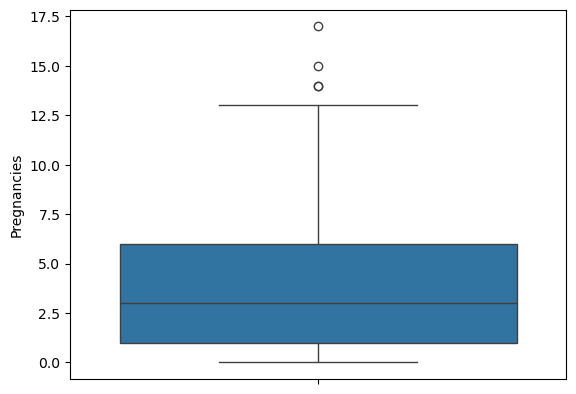

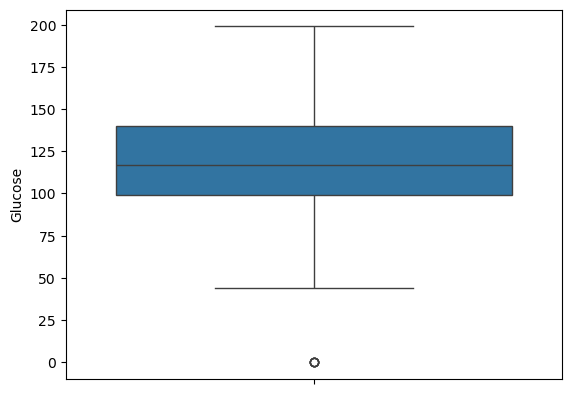

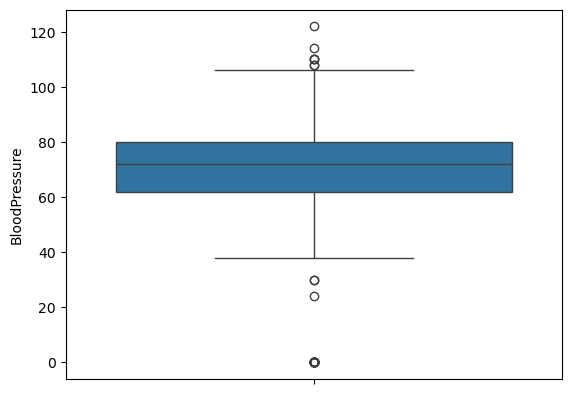

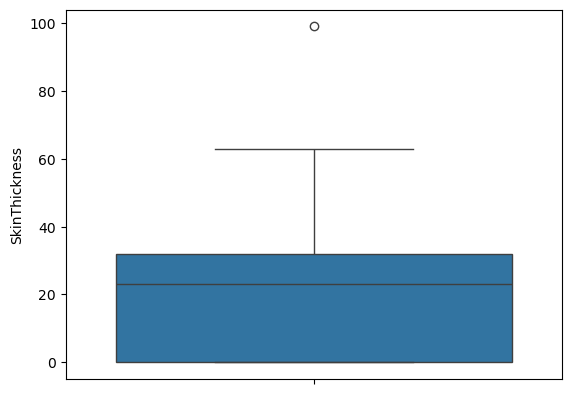

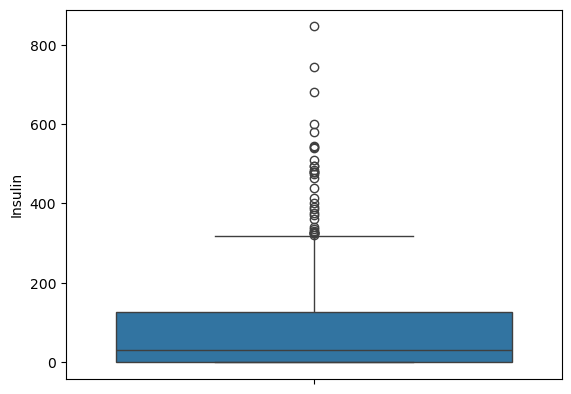

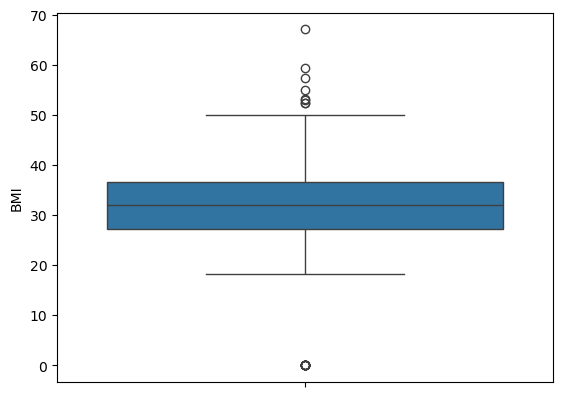

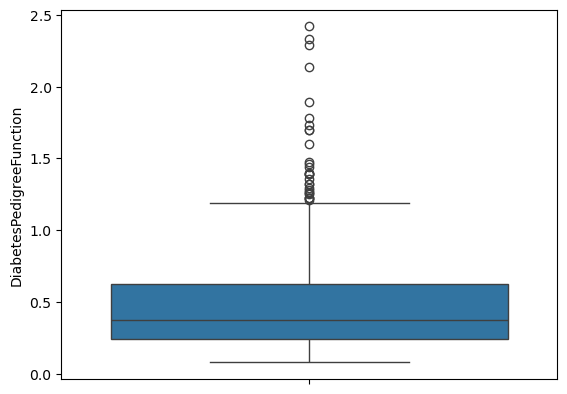

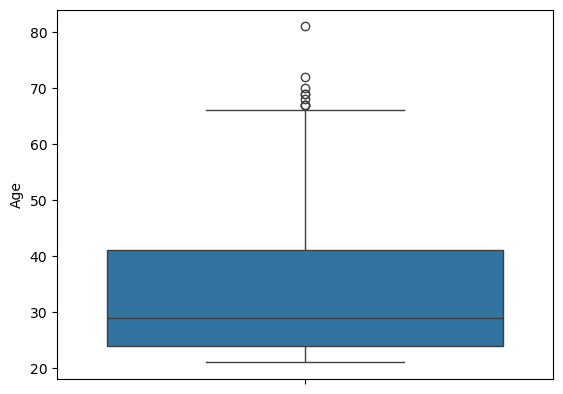

In [7]:
# Identifying outliers using boxplot
for i in x:
    sns.boxplot(df[i])
    plt.show()

#Outliers were observed in all 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
#'BMI', 'DiabetesPedigreeFunction', 'Age' columns. Since this is a medical dataset, extreme
#values may represent genuine patient conditions rather than data errors.

In [8]:
# skewness check
from scipy.stats import skew
for i in x:
    print(f"{i} : {skew(df[i])}")


# Highly Positive skewed - Insulin , DiabetesPedigreeFunction , Age
# Highly Negative skewed - BloodPressure
# Some features were highly skewed, which is common in healthcare datasets
# due to natural variation in patient medical values.
# Therefore, skewness transformation was not applied to preserve original medical information.

Pregnancies : 0.8999119408414357
Glucose : 0.17341395519987735
BloodPressure : -1.8400052311728738
SkinThickness : 0.109158762323673
Insulin : 2.2678104585131753
BMI : -0.42814327880861786
DiabetesPedigreeFunction : 1.9161592037386292
Age : 1.127389259531697


In [9]:
# Handle invalid zero values
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

# Some medical features contained invalid zero values.
# Since zero is not medically valid for these measurements,
# zeros were replaced with median values of respective columns.

In [10]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


In [11]:
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

In [12]:
#scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Scaling was performed after train-test split to prevent data leakage and ensure that statistical information from test data was
#not used during training.

In [13]:
# using smote technique to handle imbalance data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [14]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

# The dataset was imbalanced with fewer diabetic cases.
# SMOTE (Synthetic Minority Oversampling Technique) was applied
# on training data to balance class distribution by generating
# synthetic samples for the minority class.

Outcome
0    401
1    213
Name: count, dtype: int64
Outcome
0    401
1    401
Name: count, dtype: int64


In [15]:
# Model 1 without Hidden Layer
# Craete Model
model1 = Sequential([Dense(1, activation='sigmoid', input_shape=(8,))])

D:\DIVYA\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
#Compile Model
model1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [17]:
# Train Model
history1 = model1.fit(X_train_smote,y_train_smote,epochs=25,batch_size=32,validation_split=0.2)

Epoch 1/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3994 - loss: 1.0528 - val_accuracy: 0.3043 - val_loss: 1.1415
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4134 - loss: 1.0297 - val_accuracy: 0.3043 - val_loss: 1.1179
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4228 - loss: 1.0085 - val_accuracy: 0.3106 - val_loss: 1.0971
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4337 - loss: 0.9873 - val_accuracy: 0.3043 - val_loss: 1.0783
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4384 - loss: 0.9676 - val_accuracy: 0.3043 - val_loss: 1.0609
Epoch 6/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4415 - loss: 0.9477 - val_accuracy: 0.3043 - val_loss: 1.0424
Epoch 7/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4493 - loss: 0.9278 - val_accuracy: 0.3043 - val_loss: 1.0235
Epoch 8/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4618 - loss: 0.9091 - val_accuracy: 0.3168 - val_loss

In [18]:
#Evaluate Model
loss1, acc1 = model1.evaluate(X_test, y_test)

print("Accuracy:", acc1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5455 - loss: 0.7150
Accuracy: 0.5454545617103577


In [19]:
#Predictions
y_pred1 = (model1.predict(X_test) > 0.5).astype("int32")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [20]:
# Classification Report
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.66      0.60      0.63        99
           1       0.38      0.45      0.42        55

    accuracy                           0.55       154
   macro avg       0.52      0.53      0.52       154
weighted avg       0.56      0.55      0.55       154



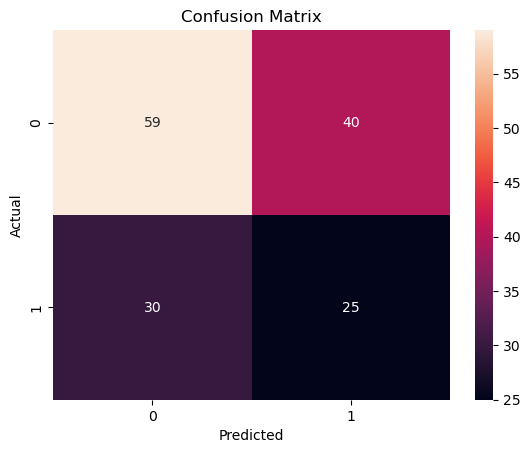

In [21]:
cm = confusion_matrix(y_test, y_pred1)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()



# A binary classifier without hidden layers was implemented using TensorFlow.
# The model directly maps input features to output using sigmoid activation.

In [22]:
# Model 2 - one hidden layer and one dropout layer.

# Model 2 was developed by adding one hidden layer and one dropout layer.
# ReLU activation was used in hidden layer to learn complex patterns,
# while dropout was used to reduce overfitting.

# Create Model

model2 = Sequential([
    Dense(16, activation='relu', input_shape=(8,)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

D:\DIVYA\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
#Model Summary
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Compile Model
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
#Train Model
history2 = model2.fit(
    X_train_smote,
    y_train_smote,
    epochs=25,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5039 - loss: 0.7498 - val_accuracy: 0.4783 - val_loss: 0.7305
Epoch 2/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5803 - loss: 0.6900 - val_accuracy: 0.4720 - val_loss: 0.7370
Epoch 3/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5803 - loss: 0.6758 - val_accuracy: 0.4783 - val_loss: 0.7459
Epoch 4/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5975 - loss: 0.6413 - val_accuracy: 0.4783 - val_loss: 0.7506
Epoch 5/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6412 - loss: 0.6245 - val_accuracy: 0.4783 - val_loss: 0.7513
Epoch 6/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6365 - loss: 0.6235 - val_accuracy: 0.4783 - val_loss: 0.7428
Epoch 7/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6583 - loss: 0.6007 - val_accuracy: 0.4907 - val_loss: 0.7352
Epoch 8/25
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6771 - loss: 0.5869 - val_accuracy: 0.5093 - val_los

In [26]:
# Evaluate Model
loss2, acc2 = model2.evaluate(X_test, y_test)

print("Model 2 Accuracy:", acc2)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7662 - loss: 0.5027
Model 2 Accuracy: 0.7662337422370911


In [27]:
# Predictions
y_pred2 = (model2.predict(X_test) > 0.5).astype("int32")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [28]:
# Classification Report
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



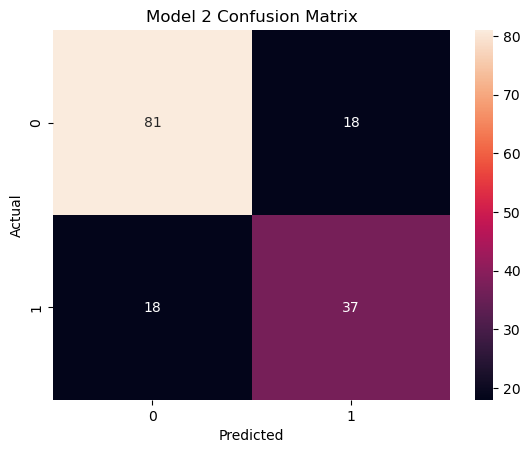

In [29]:
# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred2)

sns.heatmap(cm2, annot=True, fmt='d')

plt.title("Model 2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
# Compare both models
print("Model 1 Accuracy :", acc1)
print("Model 2 Accuracy :", acc2)

Model 1 Accuracy : 0.5454545617103577
Model 2 Accuracy : 0.7662337422370911


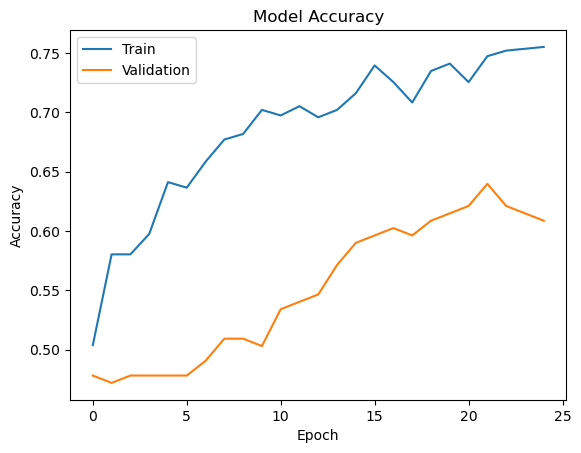

In [31]:
# Accuracy Graph
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

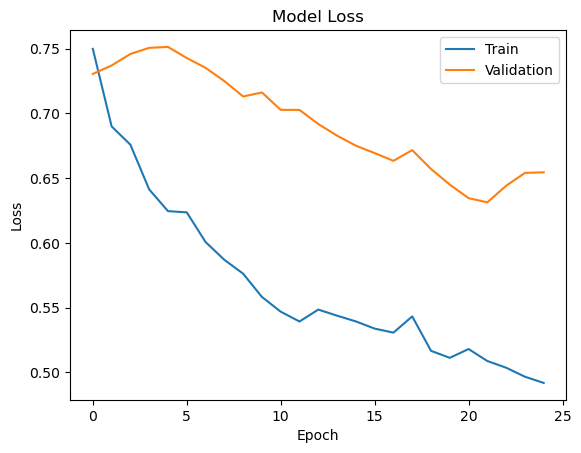

In [32]:
# Loss Graph
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [33]:
model2.save("diabetes_model.h5")

In [34]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']